In [1]:
import os
import numpy as np
import pandas as pd
import datetime
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# 1. Folder structure setup
horizons = [6, 12, 24, 48, 72]
feature_types = ['UNIVARIATE', 'MULTIVARIATE']

for ft in feature_types:
    for h in horizons:
        base_path = f"{ft}/{h}h"
        os.makedirs(f"{base_path}/dataset_ready", exist_ok=True)
        os.makedirs(f"{base_path}/LOSS", exist_ok=True)
        os.makedirs(f"{base_path}/MODELS", exist_ok=True)
        os.makedirs(f"{base_path}/results", exist_ok=True)
print("Folder structure created successfully!")

Num GPUs Available:  0
Folder structure created successfully!


In [13]:
# 2. Data Loading & Setup
import pickle

df = pd.read_csv("df_combined_AT.csv")
df_dummy = df.drop(columns=['utc_timestamp'])

# Normalisasi menggunakan log untuk rain dan relative humidity
df_dummy['rain (mm)'] = np.log1p(df_dummy['rain (mm)'])
df_dummy['relative_humidity_2m (%)'] = np.log1p(df_dummy['relative_humidity_2m (%)'])

# Normalize the data using 80% train assumptions
train_idx = int(df_dummy.shape[0] * 0.8)
scaler = MinMaxScaler()
scaler.fit(df_dummy[:train_idx]) 
scaled_data = scaler.transform(df_dummy)

# Save the scaler and the scaled data
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
np.save('scaled_data.npy', scaled_data)

print("Data loaded and scaled! Shape:", scaled_data.shape)
print("Saved scaler to 'scaler.pkl' and scaled data to 'scaled_data.npy'")

Data loaded and scaled! Shape: (50400, 5)
Saved scaler to 'scaler.pkl' and scaled data to 'scaled_data.npy'


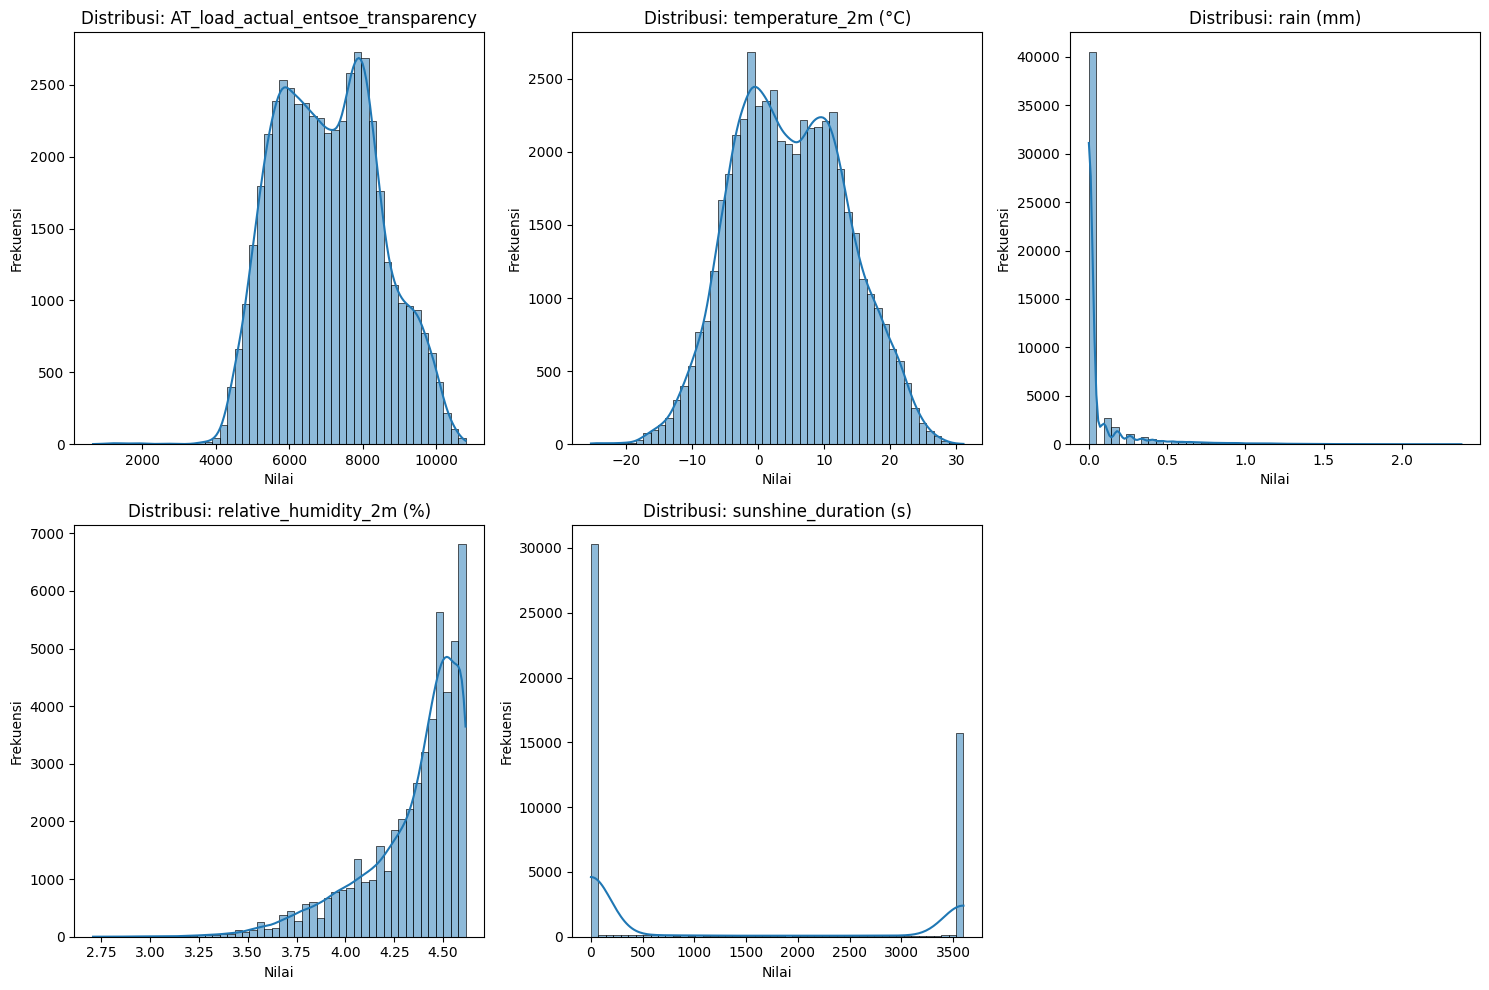

,AT_load_actual_entsoe_transparency,temperature_2m (°C),rain (mm),relative_humidity_2m (%),sunshine_duration (s)
count,50400.000000,50400.000000,50400.000000,50400.000000,50400.000000
mean,7070.148631,4.873226,0.074870,4.342425,1268.193835
std,1400.263167,8.543645,0.215574,0.260734,1664.802739
min,664.000000,-25.300000,0.000000,2.708050,0.000000
25%,5941.000000,-1.600000,0.000000,4.219508,0.000000
50%,7032.000000,4.500000,0.000000,4.430817,0.000000
75%,8079.000000,11.100000,0.000000,4.532599,3600.000000
max,10803.000000,31.100000,2.379546,4.615121,3600.000000


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi distribusi dari raw data sebelum di-scaling
plt.figure(figsize=(15, 10))
for i, col in enumerate(df_dummy.columns):
    plt.subplot(len(df_dummy.columns) // 3 + 1, 3, i + 1)
    sns.histplot(df_dummy[col], bins=50, kde=True)
    plt.title(f'Distribusi: {col}')
    plt.xlabel('Nilai')
    plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# Menampilkan statistik deskriptif dari data
display(df_dummy.describe())

In [3]:
# 3. Helper Functions
def create_supervised_data(scaled_data_x, scaled_data_y, lag, horizon):
    X, y = [], []
    for i in range(lag, len(scaled_data_x) - horizon + 1):
        X.append(scaled_data_x[i - lag:i, :]) 
        y.append(scaled_data_y[i:i + horizon]) 
    return np.array(X), np.array(y)

def train_val_test_split(X, y, train_ratio=0.8, val_ratio=0.1):
    total = len(X)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)
    return X[:train_end], y[:train_end], X[train_end:val_end], y[train_end:val_end], X[val_end:], y[val_end:]

def get_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero = y_true != 0
    if not np.any(non_zero): return np.nan
    return np.mean(np.abs((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero])) * 100

def get_row_mapes(y_true, y_pred):
    mapes = []
    for i in range(len(y_true)):
        non_zero = y_true[i] != 0
        if np.any(non_zero):
            m = np.mean(np.abs((y_true[i][non_zero] - y_pred[i][non_zero]) / y_true[i][non_zero])) * 100
        else:
            m = np.nan
        mapes.append(m)
    return mapes

In [ ]:
# 4. Model Architectures
def build_lstm(seq_len, num_d, out_steps):
    inputs = layers.Input(shape=(seq_len, num_d))
    x = layers.LSTM(64, return_sequences=False)(inputs)
    outputs = layers.Dense(out_steps)(x)
    model = models.Model(inputs=inputs, outputs=outputs, name="LSTM")
    model.compile(optimizer='adam', loss='mse')
    return model

def build_bilstm(seq_len, num_d, out_steps):
    inputs = layers.Input(shape=(seq_len, num_d))
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(inputs)
    outputs = layers.Dense(out_steps)(x)
    model = models.Model(inputs=inputs, outputs=outputs, name="BiLSTM")
    model.compile(optimizer='adam', loss='mse')
    return model

def build_attention(seq_len, num_d, out_steps):
    inputs = layers.Input(shape=(seq_len, num_d))
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    attention_output = layers.MultiHeadAttention(key_dim=64, num_heads=4, dropout=0.2)(x, x)
    x = layers.Add()([attention_output, inputs])
    x2 = layers.LayerNormalization(epsilon=1e-6)(x)
    x2 = layers.Dense(64, activation="relu")(x2)
    x2 = layers.Dropout(0.2)(x2)
    x2 = layers.Dense(num_d)(x2)
    x = layers.Add()([x2, x])
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(out_steps)(x)
    model = models.Model(inputs=inputs, outputs=outputs, name="Attention")
    model.compile(optimizer='adam', loss='mse')
    return model

In [10]:
print(df_dummy.columns.tolist())

['AT_load_actual_entsoe_transparency', 'temperature_2m (°C)', 'rain (mm)', 'relative_humidity_2m (%)', 'sunshine_duration (s)']


In [7]:
scaled_data_x = scaled_data
scaled_data_y = scaled_data[:, 0]       # Target is always load
        
lag = 24
h = 6

# Sliding windows
X_all, y_all = create_supervised_data(scaled_data_x, scaled_data_y, lag=lag, horizon=h)

# Train/Val/Test Split manually using train_idx
# array index K in X_all/y_all corresponds to raw data index [lag + K]
# We want Test to start exactly at raw data index = train_idx
test_split_idx = train_idx - lag

X_train_val = X_all[:test_split_idx]
y_train_val = y_all[:test_split_idx]

X_test = X_all[test_split_idx:]
y_test = y_all[test_split_idx:]

# Split train_val into Train and Val (e.g. 80% train, 20% val)
val_split_idx = int(len(X_train_val) * 0.8)
X_train, y_train = X_train_val[:val_split_idx], y_train_val[:val_split_idx]
X_val, y_val = X_train_val[val_split_idx:], y_train_val[val_split_idx:]

print(f"scaled_data.shape: {scaled_data.shape}")
print(f"scaled_data_x.shape: {scaled_data_x.shape}")
print(f"scaled_data_y.shape: {scaled_data_y.shape}")
print(f"x_all.shape: {X_all.shape}")
print(f"y_all.shape: {y_all.shape}")
print(f"train_idx: {train_idx}")
print(f"test_split_idx: {test_split_idx}")
print(f"X_train_val.shape: {X_train_val.shape}")
print(f"y_train_val.shape: {y_train_val.shape}")
print(f"X_train.shape: {X_train.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"X_val.shape: {X_val.shape}")
print(f"y_val.shape: {y_val.shape}")
print(f"X_test.shape: {X_test.shape}")
print(f"y_test.shape: {y_test.shape}")

scaled_data.shape: (50400, 5)
scaled_data_x.shape: (50400, 5)
scaled_data_y.shape: (50400,)
x_all.shape: (50371, 24, 5)
y_all.shape: (50371, 6)
train_idx: 40320
test_split_idx: 40296
X_train_val.shape: (40296, 24, 5)
y_train_val.shape: (40296, 6)
X_train.shape: (32236, 24, 5)
y_train.shape: (32236, 6)
X_val.shape: (8060, 24, 5)
y_val.shape: (8060, 6)
X_test.shape: (10075, 24, 5)
y_test.shape: (10075, 6)


In [8]:
# Validasi Timestamp dan Konsistensi Index Sliding Window
print("\n--- VALIDASI INDEX TIME SERIES ---")

# 1. Cek Ujung Train vs Awal Validation (Dalam X_train_val)
akhir_train_idx_raw = lag + val_split_idx - 1
awal_val_idx_raw = lag + val_split_idx

print(f"Index Actual di Data Mentah (Akhir Train): {akhir_train_idx_raw} | Timestamp: {df['utc_timestamp'].iloc[akhir_train_idx_raw]}")
print(f"Index Actual di Data Mentah (Awal Validation): {awal_val_idx_raw} | Timestamp: {df['utc_timestamp'].iloc[awal_val_idx_raw]}")

# 2. Cek Ujung Validation vs Awal Test (Batasan Tersulit - Scaler)
akhir_val_idx_raw = train_idx - 1 
awal_test_idx_raw = train_idx # Ini harus sama dengan scaler assumption: df_dummy[:train_idx]

print(f"\nIndex Actual di Data Mentah (Akhir Val): {akhir_val_idx_raw} | Timestamp: {df['utc_timestamp'].iloc[akhir_val_idx_raw]}")
print(f"Index Actual di Data Mentah (Awal Test): {awal_test_idx_raw} | Timestamp: {df['utc_timestamp'].iloc[awal_test_idx_raw]}")

# 3. Pengecekan overlap / persimpangan di Index Window Sendiri
print("\nPengecekan Shape dan Urutan Indeks Array Model:")
print(f"X_train (Elemen terakhir, Row terakhir, Feature ke-0): {X_train[-1, -1, 0]:.4f}")
print(f"X_val (Elemen PERTAMA, Row sebelum terakhir, Feature ke-0): {X_val[0, -2, 0]:.4f}")
print("-> Jika angka di atas SAMA PERSIS, maka Sliding Window bergeser berurutan dengan benar 1 langkah!")

print(f"\nX_val (Elemen terakhir, Row terakhir, Feature ke-0): {X_val[-1, -1, 0]:.4f}")
print(f"X_test (Elemen PERTAMA, Row sebelum terakhir, Feature ke-0): {X_test[0, -2, 0]:.4f}")
print("-> Jika angka di atas SAMA PERSIS, maka Test data dimulai TEPAT setelah Validation berakhir \ntanpa celah/dengan overlap historis normal!")


--- VALIDASI INDEX TIME SERIES ---
Index Actual di Data Mentah (Akhir Train): 32259 | Timestamp: 2018-09-06 03:00:00+00:00
Index Actual di Data Mentah (Awal Validation): 32260 | Timestamp: 2018-09-06 04:00:00+00:00

Index Actual di Data Mentah (Akhir Val): 40319 | Timestamp: 2019-08-07 23:00:00+00:00
Index Actual di Data Mentah (Awal Test): 40320 | Timestamp: 2019-08-08 00:00:00+00:00

Pengecekan Shape dan Urutan Indeks Array Model:
X_train (Elemen terakhir, Row terakhir, Feature ke-0): 0.4647
X_val (Elemen PERTAMA, Row sebelum terakhir, Feature ke-0): 0.4647
-> Jika angka di atas SAMA PERSIS, maka Sliding Window bergeser berurutan dengan benar 1 langkah!

X_val (Elemen terakhir, Row terakhir, Feature ke-0): 0.4661
X_test (Elemen PERTAMA, Row sebelum terakhir, Feature ke-0): 0.4661
-> Jika angka di atas SAMA PERSIS, maka Test data dimulai TEPAT setelah Validation berakhir 
tanpa celah/dengan overlap historis normal!


In [ ]:
# 5. Massive Experiment Loop
epochs = 200
batch_size = 32
lag = 24  # Standard lag looking back 24 hours

for ft in feature_types:
    for h in horizons:
        print(f"\n{'='*60}\n--> STARTING EXPERIMENT: Feature = {ft} | Horizon = {h}h\n{'='*60}")
        base_path = f"{ft}/{h}h"
        
        # Determine X and y shapes based on Univariate vs Multivariate
        if ft == 'UNIVARIATE':
            scaled_data_x = scaled_data[:, 0:1] # Only keep load
        else:
            scaled_data_x = scaled_data         # Keep load + weather data
        
        scaled_data_y = scaled_data[:, 0]       # Target is always load
        
        # Sliding windows
        X_all, y_all = create_supervised_data(scaled_data_x, scaled_data_y, lag=lag, horizon=h)
        
        # Train/Val/Test Split manually using train_idx
        # array index K in X_all/y_all corresponds to raw data index [lag + K]
        # We want Test to start exactly at raw data index = train_idx
        test_split_idx = train_idx - lag
        
        X_train_val = X_all[:test_split_idx]
        y_train_val = y_all[:test_split_idx]
        
        X_test = X_all[test_split_idx:]
        y_test = y_all[test_split_idx:]
        
        # Split train_val into Train and Val (e.g. 80% train, 20% val)
        val_split_idx = int(len(X_train_val) * 0.8)
        X_train, y_train = X_train_val[:val_split_idx], y_train_val[:val_split_idx]
        X_val, y_val = X_train_val[val_split_idx:], y_train_val[val_split_idx:]
        
        # Save datasets
        np.save(f"{base_path}/dataset_ready/X_train.npy", X_train)
        np.save(f"{base_path}/dataset_ready/y_train.npy", y_train)
        np.save(f"{base_path}/dataset_ready/X_val.npy", X_val)
        np.save(f"{base_path}/dataset_ready/y_val.npy", y_val)
        np.save(f"{base_path}/dataset_ready/X_test.npy", X_test)
        np.save(f"{base_path}/dataset_ready/y_test.npy", y_test)
        
        # Extract variables for models
        seq_len = X_train.shape[1]
        num_d = X_train.shape[2]
        out_steps = y_train.shape[1]
        
        # Dynamically extract correctly-aligned timestamps for test predictions DataFrame
        test_start_idx_for_ts = train_idx
        test_timestamps = df['utc_timestamp'].iloc[test_start_idx_for_ts : test_start_idx_for_ts + len(y_test)].values
        
        # Model List
        models_dict = {
            "LSTM": build_lstm(seq_len, num_d, out_steps),
            "BiLSTM": build_bilstm(seq_len, num_d, out_steps),
            "Attention": build_attention(seq_len, num_d, out_steps)
        }
        
        for name, model in models_dict.items():
            print(f"\n--- Training {name} ({ft} - {h}h) ---")
            
            # Train
            history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs, batch_size=batch_size, verbose=1)
            
            # Save Loss
            train_loss = history.history['loss']
            val_loss = history.history['val_loss']
            np.save(f"{base_path}/LOSS/loss_{name}.npy", np.array([train_loss, val_loss]))
            
            plt.figure(figsize=(8, 5))
            plt.plot(train_loss, label='Train Loss')
            plt.plot(val_loss, label='Val Loss')
            plt.title(f'{name} ({ft} - {h}h) Loss')
            plt.legend()
            plt.grid()
            plt.savefig(f"{base_path}/LOSS/loss_{name}.png")
            plt.close()
            
            # Save Model
            model.save(f"{base_path}/MODELS/{name}.h5")
            
            # Predict
            pred_train = model.predict(X_train)
            pred_test = model.predict(X_test)
            
            mape_train = get_mape(y_train, pred_train)
            mape_test = get_mape(y_test, pred_test)
            
            # Global CSV logging
            date_str = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            global_csv_path = "global_summary.csv"
            new_row = pd.DataFrame([{
                'datetime_run': date_str,
                'feature_type': ft,
                'horizon': f"{h}h",
                'model_name': name,
                'mape_train': round(mape_train, 4),
                'mape_test': round(mape_test, 4)
            }])
            new_row.to_csv(global_csv_path, mode='a', header=not os.path.exists(global_csv_path), index=False)

            print(f"--> {name} Train MAPE: {mape_train:.4f} | Test MAPE: {mape_test:.4f}")
            
            # CSV Save
            row_mapes = get_row_mapes(y_test, pred_test)
            
            # Flaten lags for CSV (since it can be 2D arrays)
            lag_strs = [str(list(x.flatten())) for x in X_test]
            act_strs = [str(list(y)) for y in y_test]
            pred_strs = [str(list(p)) for p in pred_test]
            
            df_res = pd.DataFrame({
                'DATE_OF_DATA_POINT': test_timestamps,
                'LAG_DATA': lag_strs,
                'ACTUAL_VALUE_HORIZON': act_strs,
                'PREDICTED_VALUE_HORIZON': pred_strs,
                'MAPE_OF_THIS_DATA_POINT': row_mapes
            })
            df_res.to_csv(f"{base_path}/results/{name}.csv", index=False)

In [ ]:
# 6. Evaluation Only Loop 
# (Re-evaluate saved models without retraining, using the EXACT splits in this notebook)
from tensorflow.keras.models import load_model
import os
import pandas as pd
import numpy as np

# Change base_dir to 'KAGGLE_RESULTS_FIX' if you want to evaluate models from that folder
# Or keep it as '' to evaluate models from the current working directory
base_dir = 'KAGGLE_RESULTS_FIX' 

models_list = ['LSTM', 'BiLSTM', 'Attention']
lag = 24

for ft in feature_types:
    for h in horizons:
        print(f"\n{'='*60}\n--> STARTING EVALUATION: Feature = {ft} | Horizon = {h}h\n{'='*60}")
        
        # Path to read and write
        path_prefix = f"{base_dir}/{ft}/{h}h" if base_dir else f"{ft}/{h}h"
        
        # Determine X and y shapes based on Univariate vs Multivariate
        if ft == 'UNIVARIATE':
            scaled_data_x = scaled_data[:, 0:1] # Only keep load
        else:
            scaled_data_x = scaled_data         # Keep load + weather data
        
        scaled_data_y = scaled_data[:, 0]       # Target is always load
        
        # Sliding windows
        X_all, y_all = create_supervised_data(scaled_data_x, scaled_data_y, lag=lag, horizon=h)
        
        # Train/Val/Test Split manually using train_idx EXACTLY like your training loop
        test_split_idx = train_idx - lag
        
        X_test = X_all[test_split_idx:]
        y_test = y_all[test_split_idx:]
        
        # Dynamically extract correctly-aligned timestamps for test predictions DataFrame
        test_start_idx_for_ts = train_idx
        test_timestamps = df['utc_timestamp'].iloc[test_start_idx_for_ts : test_start_idx_for_ts + len(y_test)].values
        
        for name in models_list:
            model_path = f"{path_prefix}/MODELS/{name}.h5"
            
            # Cek jika file memakai affix _yj (Yeo-Johnson)
            if not os.path.exists(model_path):
                model_path = f"{path_prefix}/MODELS/{name}_yj.h5"
                
            if not os.path.exists(model_path):
                print(f"Model {name} not found at {model_path}. Skipping...")
                continue
                
            print(f"Evaluating {name} from {model_path}...")
            model = load_model(model_path)
            
            # Predict only on Test set
            pred_test = model.predict(X_test)
            mape_test = get_mape(y_test, pred_test)
            
            print(f"--> {name} Test MAPE: {mape_test:.4f}")
            
            # CSV Save
            row_mapes = get_row_mapes(y_test, pred_test)
            
            lag_strs = [str(list(x.flatten())) for x in X_test]
            act_strs = [str(list(y)) for y in y_test]
            pred_strs = [str(list(p)) for p in pred_test]
            
            df_res = pd.DataFrame({
                'DATE_OF_DATA_POINT': test_timestamps,
                'LAG_DATA': lag_strs,
                'ACTUAL_VALUE_HORIZON': act_strs,
                'PREDICTED_VALUE_HORIZON': pred_strs,
                'MAPE_OF_THIS_DATA_POINT': row_mapes
            })
            
            save_dest = f"{path_prefix}/results"
            os.makedirs(save_dest, exist_ok=True)
            df_res.to_csv(f"{save_dest}/{name}.csv", index=False)
            print(f"Saved evaluation wrapper to {save_dest}/{name}.csv")